In [2]:
import xgi
import numpy as np
import sys
import os
# __file__ is not defined in Jupyter, use current working directory instead
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..', 'edge_rewiring')))
from sod.simpliciality import edit_simpliciality, face_edit_simpliciality, simplicial_fraction

In [3]:
import matplotlib.pyplot as plt
from edge_rewiring import model_generation
lst = []
for i in range(500, 10000, 100):
    H_es = model_generation.model_generation_es(es=0.3, approx_num_C=i, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=10)
    m = H_es.nodes.multi(['degree', 'clustering_coefficient']).asdict()
    #print(m)
    es = edit_simpliciality(H_es, min_size=2)
    lst.append(es)
    #print(f"Edit simpliciality: {es}")
    
print(lst)
plt.plot(range(500, 10000, 100), lst, marker='o')
plt.show()

C_distribution: [71 41 23 51 63 32 68 73 57 21]
C_distribution: [61 70 17 74 46 92 45 34 77 84]
C_distribution: [ 69 110  73  61  41  46  83  94  85  38]
C_distribution: [ 62  61 165 105  22  25 117  52  59 132]
C_distribution: [ 56  78 126  99 117  43  97  76 113  95]
C_distribution: [128 140  51  82 160  66 108  66 110  89]
C_distribution: [123 100  80 163  94  47 186  61  89 157]
C_distribution: [113 112 140 176 197 115  73  89  34 151]
C_distribution: [148 136 183 200 122  79  94 182  58  98]
C_distribution: [156 174 158 141 214  51 158 126  82 140]
C_distribution: [147 251 185 134  99 106  25  82 207 264]
C_distribution: [115  81  10 134 129 209 223 299 155 245]
C_distribution: [124 187 190 188  91 142 147 293 168 170]
C_distribution: [233 147 183 337 278 155  87 122 180  78]
C_distribution: [ 96 241 223 284 216 230 179 192 121 118]
C_distribution: [287 416 204 199 113  12 101 345 133 190]
C_distribution: [302 189 240 221  30 106 274 168 280 290]
C_distribution: [ 89 221  83 239 2

KeyboardInterrupt: 

C_distribution: [ 677 1444    1 1081  942  855 1758  814 1498  930]
C_distribution: [1273  620 1459  586 1948  806 1186 1894  685  543]
C_distribution: [1113  868  939  357  572 2091 1350 1361 2458  891]
C_distribution: [1335 1529 1223 1325 2132 1331  309  893 1284 1639]
C_distribution: [1391 1720  884  927 1631 1825 1323 1220  945 2134]
C_distribution: [ 965 1036 1761 1050 1561 2592 1207 1042 1756 2030]
C_distribution: [2295 1522 3004 1309 1253 1739 1457  644  593 2184]
C_distribution: [1601  753 2038 2153 1186  695 2537 2454 2580 1003]
C_distribution: [1830 1697 2699 1312 1455 3659 1156 2029 1264  899]
C_distribution: [ 591 2042 1363 1372 2472 2690 2085 1834 1716 2835]
[0.3, 0.30003279763857005, 0.300031867431485, 0.30001511411154214, 0.30003102699348433, 0.3000374111485223, 0.30002044571662234, 0.3000072658577345, 0.3000298749519867, 0.30001352630867034]


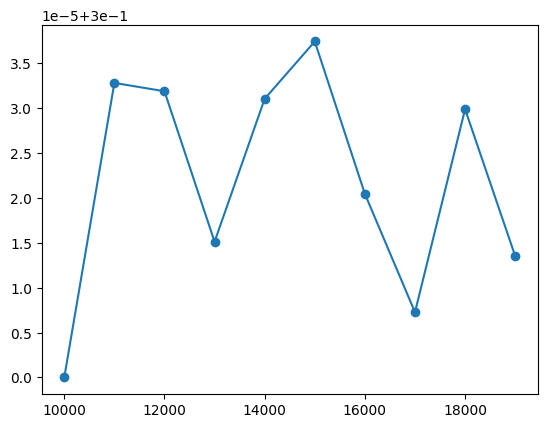

In [5]:
import matplotlib.pyplot as plt
from edge_rewiring import model_generation
lst = []
for i in range(10000, 20000, 1000):
    H_es = model_generation.model_generation_es(es=0.3, approx_num_C=i, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=10)
    m = H_es.nodes.multi(['degree', 'clustering_coefficient']).asdict()
    #print(m)
    es = edit_simpliciality(H_es, min_size=2)
    lst.append(es)
    #print(f"Edit simpliciality: {es}")
    
print(lst)
plt.plot(range(10000, 20000, 1000), lst, marker='o')
plt.show()

Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'es_new' on <module '__main__' (built-in)>
Traceback (most recent call last):
  File "<string>", line 1, in <module>
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/spawn.py", line 116, in spawn_main
    exitcode = _main(fd, parent_sentinel)
  File "/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/multiprocessing/spawn.py", line 126, in _main
    self = reduction.pickle.load(from_parent)
AttributeError: Can't get attribute 'es_new' on <module '__main__' (built-in)>
Traceback (most recent call 

[]


ValueError: x and y must have same first dimension, but have shapes (20,) and (0,)

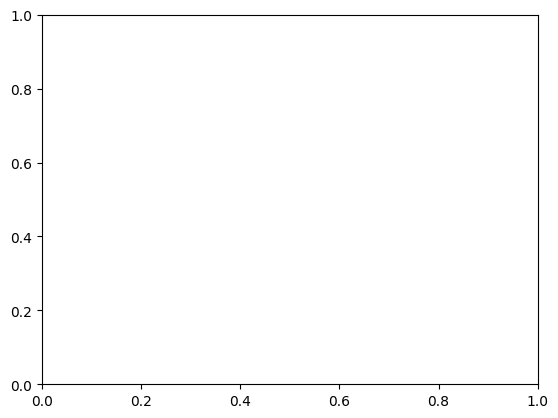

In [6]:
import matplotlib.pyplot as plt
from edge_rewiring import model_generation
from multiprocessing import Process, Manager
def es_new (es, approx_num_C, num_max_hyperedge, num_node, min_size, max_size, lst):
    H_es = model_generation.model_generation_es
    es = edit_simpliciality(H_es, min_size=2)
    lst.append(es)

with Manager() as manager:
    lst = manager.list()    
    processes = []
    for i in range(1, 200, 10): 
        p = Process(target=es_new, args=(0.4, 30, i, 200, 2, 10, lst))
        processes.append(p)
        p.start() 
        
    for p in processes:
        p.join()  
        
    print(lst)
    
    plt.plot(range(1, 200, 10), lst, marker='o')
    plt.show()

In [ ]:
# Note the cmultiedge related methods in xgi are really confusing/weird. Try avoid using it.
# Below is an example of multiedge method not working
H = xgi.Hypergraph()
nodes = [i for i in range(10)]
H.add_nodes_from(nodes)
H.add_edge({1, 10})
H.add_edge({2, 10})
H.add_edge({4,8})
H.add_edge({1, 2, 10})
m = H.nodes.multi(['degree', 'clustering_coefficient'])
print(m.asdict())
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(multiedges=True)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")
H.cleanup(singletons=True)
es = edit_simpliciality(H, min_size=2)
fes = face_edit_simpliciality(H, min_size=2)
print(f"Edit simpliciality: {es}")
print(f"Face edit simpliciality: {fes}")

{0: {'degree': 0, 'clustering_coefficient': 0.0}, 1: {'degree': 2, 'clustering_coefficient': 1.0}, 2: {'degree': 2, 'clustering_coefficient': 1.0}, 3: {'degree': 0, 'clustering_coefficient': 0.0}, 4: {'degree': 1, 'clustering_coefficient': 0.0}, 5: {'degree': 0, 'clustering_coefficient': 0.0}, 6: {'degree': 0, 'clustering_coefficient': 0.0}, 7: {'degree': 0, 'clustering_coefficient': 0.0}, 8: {'degree': 1, 'clustering_coefficient': 0.0}, 9: {'degree': 0, 'clustering_coefficient': 0.0}, 10: {'degree': 3, 'clustering_coefficient': 1.0}}
Edit simpliciality: 0.8
Face edit simpliciality: 0.6666666666666666
Edit simpliciality: 0.75
Face edit simpliciality: 0.6666666666666666
Edit simpliciality: 0.75
Face edit simpliciality: 0.6666666666666666


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (12,8) # make figures big for easier viewing 
                                        #    (width, height in inches)
# Experiment to find the relationship between edit simpliciality and face edit simpliciality
# for a range of edit simpliciality values
es = []
fes = []
float_range = np.arange(0, 1, 0.02)
for i in range(len(float_range)):
	H = model_generation.edge_rewire_model(edit_simpliciality=float_range[i], approx_num_C=5000, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
	es.append(edit_simpliciality(H, min_size=2))
	fes.append(face_edit_simpliciality(H, min_size=2))
fig, ax = plt.subplots()
ax.plot(es, fes, color='red')

### DO THIS: Add the line of code to plot the trajectory here

ax.set_xlabel('es')
ax.set_ylabel('fes')
# An example of implicit line continuation. Python knows to keep on reading to
#    the next line because the set of parentheses hasn't been closed by the end
#    of the first line.
ax.set_title("velocity vs mass".
             format(es, fes))
plt.show()


AttributeError: module 'edge_rewiring.model_generation' has no attribute 'edge_rewire_model'

selected_edge_idx: 1
Adding edge: [(454, 595), (454, 767), (454, 417), (595, 767), (595, 417), (767, 417), (454, 595, 767), (454, 595, 417), (454, 767, 417), (595, 767, 417), (454, 595, 767, 417)]
selected_edge_idx: 0
Adding edge: [(454, 595), (454, 767), (454, 417), (595, 767), (595, 417), (767, 417), (454, 595, 767), (454, 595, 417), (454, 767, 417), (595, 767, 417), (454, 595, 767, 417)]
selected_edge_idx: 6
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 1546), (109, 1868, 1546), (1421, 109, 1868, 1546)]
selected_edge_idx: 10
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 1546), (109, 1868, 1546), (1421, 109, 1868, 1546)]
selected_edge_idx: 4
Adding edge: [(1421, 109), (1421, 1868), (1421, 1546), (109, 1868), (109, 1546), (1868, 1546), (1421, 109, 1868), (1421, 109, 1546), (1421, 1868, 15

XGIError: Every node must be a member of an edge to avoid divide by zero error!

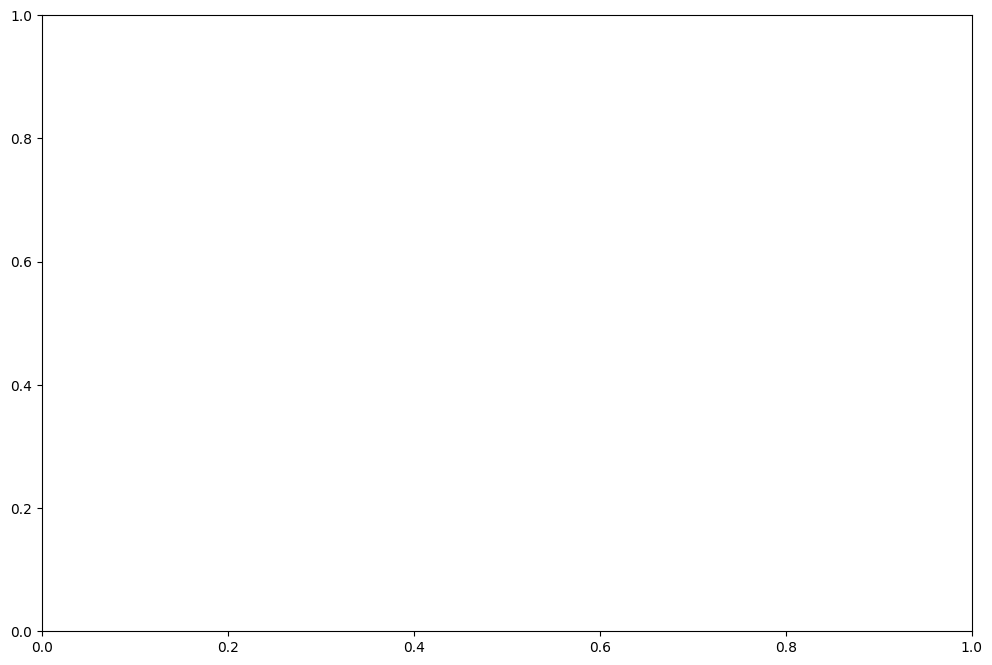

In [ ]:
node = []
cc = []
# Experiment to find the relationship between edit simpliciality and clustering coefficient
fig, ax = plt.subplots()
for i in range(10):
    H = model_generation.edge_rewire_model(0.5, approx_num_C=50, num_max_hyperedge=10,num_node=2000, min_size=2, max_size=None)
    community_clustering = xgi.spectral_clustering(H)
    print(community_clustering)
# 	for idx in range(len(clustering_coefficient)):
# 		node.append(idx)
# 		cc.append(clustering_coefficient[idx])
# ax.scatter(node, cc, color='red')
     



# ### DO THIS: Add the line of code to plot the trajectory here

# ax.set_xlabel('node')
# ax.set_ylabel('cc')
# # An example of implicit line continuation. Python knows to keep on reading to
# #    the next line because the set of parentheses hasn't been closed by the end
# #    of the first line.
# ax.set_title("node vs cc".
#              format(node, cc))
# plt.show()

In [ ]:
print(es)
print(fes)

[nan, nan, nan, nan, nan, nan, nan, 0.13333333333333333, 0.14814814814814814, 0.15789473684210525, 0.19626168224299065, 0.21212121212121213, 0.23529411764705882, 0.2589928057553957, 0.2777777777777778, 0.2937062937062937, 0.31794871794871793, 0.3350253807106599, 0.3564356435643564, 0.3799126637554585, 0.39914163090128757, 0.4147727272727273, 0.4365079365079365, 0.4576923076923077, 0.47619047619047616, 0.5, 0.5171102661596958, 0.5410447761194029, 0.5610687022900763, 0.5811320754716981, 0.6015037593984962, 0.6226415094339622, 0.6428571428571429, 0.6617100371747212, 0.6830188679245283, 0.7034220532319392, 0.7234848484848485, 0.7406015037593985, 0.7604562737642585, 0.7832699619771863, 0.8, 0.8202247191011236, 0.8435114503816794, 0.8609022556390977, 0.8830188679245283, 0.9018867924528302, 0.9201520912547528, 0.9405204460966543, 0.9619771863117871, 0.9811320754716981]
[nan, nan, nan, nan, nan, nan, nan, 0.0, 0.0, 0.0, 0.06933333333333333, 0.10424242424242425, 0.06, 0.13725490196078433, 0.123